<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ36aRaP-O1Sp0mzIRnmnZrE4yvLUuX6_dIog&s" width=500>

# **Seminario Tendencias de la Inteligencia Artificial en Salud**

# ***Deep Learning***

# **Ejemplo:** Clasificando Radiografías de Tuberculosis (TB)

**Alvaro David Orjuela Cañón, D.Sc.**

Profesor Asociado de Carrera

Escuela de Medicina y Ciencias de la Salud

alvaro.orjuela@urosario.edu.co

# **Importamos herramientas de Tensorflow**

Usamos [Tensorflow](https://www.tensorflow.org/learn?hl=es-419) como *Framework* para la creación, implementación de redes neuronales.
También, es útil con algunas funciones para el preprocesamiento y facilidad de uso con imágenes.

<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTqipz-LRjYVCR1zWPdSH_wXolKX7YIfWPMAA&s" width=500>

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, Dropout, Lambda
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd


# **Cargar Datos**

Vamos a utilizar un dataset asociado a **Tuberculosis (TB) Chest X-ray Database** que se encuentra en [Kaggle - TB Dataset](https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset). Allí se encuentra una base de datos de radiografías asociadas a TB y otras de pacientes normales.

<div style="display:inline-block;vertical-align:top;">
<img src= "https://storage.googleapis.com/kaggle-datasets-images/891819/1513418/504992b51ad9441ba04dfdb40cd40910/dataset-cover.jpg?t=2021-02-16-14-35-19" width=500>

**Descargamos directamente la base de datos desde Kaggle**


* Descargamos la base de datos
* Descomprimimos

In [2]:
!curl -L -o tuberculosis-tb-chest-xray-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  663M  100  663M    0     0  62.5M      0  0:00:10  0:00:10 --:--:-- 83.2M


In [3]:
!unzip tuberculosis-tb-chest-xray-dataset.zip -d TB

Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: TB/TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1005.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1006.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1007.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1008.png  
  inflating: TB/TB_Chest_Radiography

### **Visualización de las Imágenes**

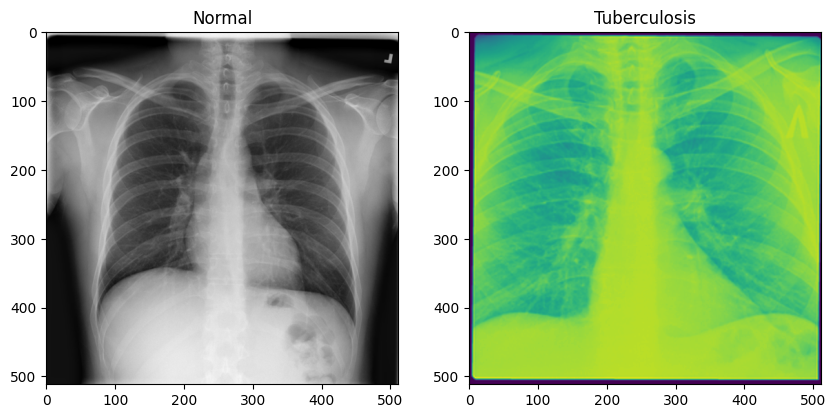

In [4]:
data_root='/content/TB/TB_Chest_Radiography_Database/'  # Dirección de la carpeta
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1) # Normal
Normal_img = plt.imread(data_root + '/Normal/Normal-10.png')
plt.imshow(Normal_img)
plt.title('Normal')

plt.subplot(1,2,2) # Tuberculosis
Tuberculosis_img = plt.imread(data_root + '/Tuberculosis/Tuberculosis-10.png')
plt.imshow(Tuberculosis_img)
plt.title('Tuberculosis')
plt.show()

### **Normalización de las Imágenes**

**Predefinimos escalamiento, zoom, rotación, entre otros factores de las imágenes**

In [6]:
# Configuración de los generadores de datos con aumento de datos sobre las imágenes más agresivo
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

### **Creación de Subconjuntos: Train-Test**

**Extraemos las imágenes para nuestros conjuntos:**
* Entrenamiento
* Validación
* Test

In [7]:
data_root='/content/TB/TB_Chest_Radiography_Database/'  # Dirección de la carpeta
IMAGE_SHAPE = (192, 192)                                # Tamaño de las imágenes
TRAINING_DATA_DIR = str(data_root)
print(TRAINING_DATA_DIR);

datagen_kwargs = dict(rescale=1./255, validation_split=.20)
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
TRAINING_DATA_DIR,
subset="validation",
shuffle=True,
target_size=IMAGE_SHAPE
)
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)

# Función generadora del conjunto de imágenes para entranmiento
train_generator = train_datagen.flow_from_directory(
TRAINING_DATA_DIR,
subset="training",
shuffle=True,
batch_size = 64,                  # Tamaño de lote para entrenar
target_size=IMAGE_SHAPE)

/content/TB/TB_Chest_Radiography_Database/
Found 840 images belonging to 2 classes.
Found 3360 images belonging to 2 classes.


Validacion 840 imagenes
Entrenamiento 3360
2 clases: TB y no TB

In [8]:
image_batch_train, label_batch_train = next(iter(train_generator))
print("Image batch shape: ", image_batch_train.shape)
print("Label batch shape: ", label_batch_train.shape)
dataset_labels = sorted(train_generator.class_indices.items(), key=lambda pair:pair[1])
dataset_labels = np.array([key.title() for key, value in dataset_labels])
print(dataset_labels)

Image batch shape:  (64, 192, 192, 3)
Label batch shape:  (64, 2)
['Normal' 'Tuberculosis']


**Notas clase:**
La GPU la prestan por tiempo limitado, por ejemplo 12 horas.
Tambien esta el TPU: ve los datos como tensores.

al elergir batch_size = 64, se divide el total de los datos 3360 en 64, osea que da: 52 lotes de 64 imagenes cada una pra entrenamiento.

Esto da : Image batch shape:  (64, 192, 192, 3)


| Dimensión | Valor | Significado |
|-----------|-------|-------------|
| 1ª        | 64    | El batch tiene 64 imágenes a la vez |
| 2ª        | 192   | Alto de cada imagen (píxeles) |
| 3ª        | 192   | Ancho de cada imagen (píxeles) |
| 4ª        | 3     | Canales de color RGB |


Y Label batch shape:  (64, 2)
que son 64 imagenes pertenecientes a dos labels

## **Visualización de las Imágenes Normalizadas**

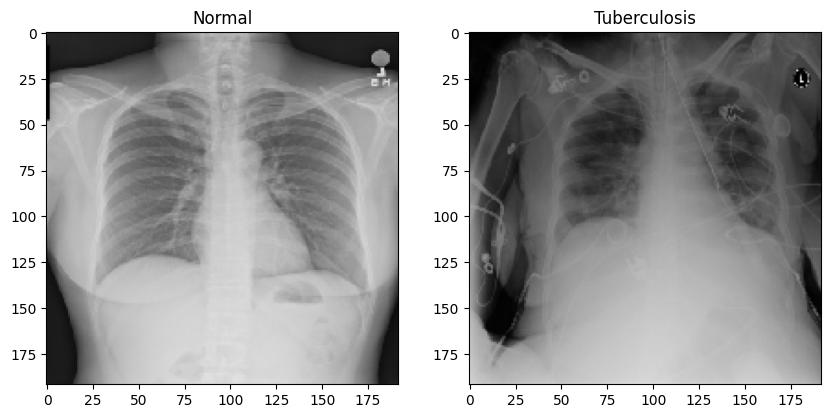

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1) # Normal
plt.imshow(image_batch_train[63])
plt.title('Normal')

plt.subplot(1,2,2) # Tuberculosis
plt.imshow(image_batch_train[0])
plt.title('Tuberculosis')
plt.show()

# **Red Neuronal Convolucional - CNN**

<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSVd3Tt86JqzsVgeZkXVoyooTt_SolBWxjXzQ&s" width=500>



### **Definiendo la Arquitectura de Nuestra Red Neuronal**


La API de Keras nos permite construir la red neuronal de dos formas:
*   Modelo Secuencial
*   Modelo Funcional

Definiremos una red de **Modelo Secuencial** agregando diferentes capas una por una:

In [11]:
def cnn_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(192,192,3)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))
    model.summary()
    return model

Dropout: apagar 25% de las neuronas
 Flatten: convertir a 1 sola capa
 Salida es de 2 neuronas

In [12]:
model1 = cnn_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 190, 190, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 95, 95, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 93, 93, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 135424)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    69,337,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,404,194 (264.76 MB)

 Trainable params: 69,404,194 (264.76 MB)

 Non-trainable params: 0 (0.00 B)

# Notas de Clase
- 69,404,194 conecciones entre neuronas.
- Peso de 265 megas en memoria de disco

En deep learning toca explorar diferentes arquitecturas.
- La idea es buscar que parametros tiene menor error, para sacar los hyperparametros.
- Como las Rx ya tienen label se puede calcular el error y medir el rendimiento del modelo. Pero en este caso tenemos ma de 69 millones de parametros, ajustarlos manualmente es imposible, por eso toca usar AI.
- Toca presentarle muchas veces las imagenes para que aprenda.
- Aprende a travez del error.
- En ML se evalua modelo por modelo y se cambian los parametros, aca es lo mismo. Se van ajustando los parameros.


La tabla anterior es como tener: Bloque 1- Bloque 2- Flatten , Dense y el Output.

- LA capa densa quedo de 512 neuronas


### **Compilando el modelo**

La red neuronal ahora se ha definido y debe completarse agregando:
* Función de costo (*loss*)
* Optimizador (*optimizer*)
* Métricas de rendimiento (*metrics*)

In [14]:
model1.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1.0e-4),
              metrics = ['accuracy'])

### **Entrenamiento del Modelo**

Establecemos unos ***checkpoints*** para guardar los diferentes valores de interés (pesos sinápticos), almancenando el archivo en un formato **.h5*. Esto nos permite tener trazabilidad de los valores de métricas importantes del rendimiento de la red neuronal.

Entrenamos con el método *fit*

In [15]:
checkpoint = ModelCheckpoint('TB_Chest_Classification.keras',
                             monitor='val_loss',
                             verbose=1,
                             save_best_only= True,
                             mode='auto')

**Notas clase:**
Acan en checkpoint lo que hace es indicar que guarde el resultado cada X tiempo, automaticamente, por si se va la luz o el internet.

In [ ]:
model_details = model1.fit(train_generator,
                    batch_size = 32,
                    epochs = 20,
                    #validation_data=val_set,
                    #validation_split= 0.1,
                    callbacks=[checkpoint],
                    verbose=1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9700 - loss: 0.0923
Epoch 1: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 696ms/step - accuracy: 0.9699 - loss: 0.0931
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.9753 - loss: 0.0852
Epoch 2: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 785ms/step - accuracy: 0.9729 - loss: 0.0872
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.9714 - loss: 0.0835
Epoch 3: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 849ms/step - accuracy: 0.9732 - loss: 0.0761
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9795 - loss: 0.0659
Epoch 4: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 779ms/step - accuracy: 0.9774 - loss: 0.0742
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.9822 - loss: 0.0611
Epoch 5: f

**Epocas**

 es que se van a tomar todas las imagenes: 3320 imagenes yse van a presentar 20 veces, osea en 20 epocas.

 **medidas del modelo:**
 Accuracy alto.
 Loss: porcentaje de error y que se estabilice. Inversamente proporcionales.


### **Evaluando los Resultados**

Tomamos datos de validación y calculamos métricas de desempeño de la red.

Generamos las imágenes de validación

In [16]:
val_image_batch, val_label_batch = next(iter(valid_generator))
true_label_ids = np.argmax(val_label_batch, axis=-1)
print("Validation batch shape:", val_image_batch.shape)

Validation batch shape: (32, 192, 192, 3)


Calculamos el desempeño sobre el conjunto de **validación** de imágenes aplicado al modelo

In [17]:
scores = model1.evaluate(val_image_batch, val_label_batch)
print("Accuracy: %.2f%%" % (scores[1]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6562 - loss: 0.6920
Accuracy: 65.62%


Tiempo de inferencia se calcula despues de entrenar l red neuronal. es el evaluate y se mide en milisegundos.

En este caso 77ms/step

In [18]:
tf_model_predictions = model1.predict(val_image_batch)
tf_pred_dataframe = pd.DataFrame(tf_model_predictions)
tf_pred_dataframe.columns = dataset_labels
print("Prediction results for the first elements")
tf_pred_dataframe

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
Prediction results for the first elements


,Normal,Tuberculosis
0,0.507267,0.492733
1,0.499869,0.500131
2,0.504671,0.495329
3,0.505402,0.494598
4,0.500392,0.499608
5,0.499848,0.500152
6,0.504561,0.495439
7,0.498562,0.501438
8,0.504441,0.495559
9,0.507857,0.492143


**Notas Clase**

Esta es la saluda de la red neuronal, las 32 imagenes evaluadas en test.

La tabla lo que dio en observacion 0:


| Observación | Normal | TB |
|-------------|--------|----|
| 0 | 1.000000e+00 | 3.497672e-16 |


Se lee:  para neurona normal es 1. y para neurona TB es 3.4 pero en negativos.
Simpre la clase mas alta gana

Estos valores estan sujetos a los pesos sinapticos y la funcion de activacion que se le dio a cada capa neuronal.

La clase es el valor mas alto: porque significa que esta neurona sobresalio con respecto a los otros. Entre mas alto mejor porque fue la neurona que mas se activo con respecto a la clase, en este caso si fue la neurona que clasifica "normal" o la que clasifica "TB"



### **Matriz de Confusión del Conjunto de Validación**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_hat_te1 = model1.predict(val_image_batch,verbose=1)
y_hat_te1 = np.argmax(y_hat_te1,axis=1)
print(classification_report(true_label_ids, y_hat_te1)) #, target_names = names))
print(confusion_matrix(true_label_ids, y_hat_te1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
              precision    recall  f1-score   support

           0       0.76      0.79      0.78        24
           1       0.29      0.25      0.27         8

    accuracy                           0.66        32
   macro avg       0.52      0.52      0.52        32
weighted avg       0.64      0.66      0.65        32

[[19  5]
 [ 6  2]]


**Notas Clase**

Classification report:

| Class        | Precision | Recall | F1-Score | Support |
|--------------|-----------|--------|----------|---------|
| 0            | 0.93      | 1.00   | 0.96     | 27      |
| 1            | 1.00      | 0.60   | 0.75     | 5       |
| accuracy     |           |        | 0.94     | 32      |
| macro avg    | 0.97      | 0.80   | 0.86     | 32      |
| weighted avg | 0.94      | 0.94   | 0.93     | 32      |

**Confusion Matrix:**

|              | Predicted 0 | Predicted 1 |
|--------------|-------------|-------------|
| **Actual 0** | 27          | 0           |
| **Actual 1** | 2           | 3           |



- Precision: ¿qué tan preciso es cuando predice positivo? 93%

- Recall:¿qué tan completo es para encontrar los positivos reales?.  sensibilidad a cada caso, por ejemplo aca para clase normal la sensibilidad fue del 100% y para clasificacion TB fue del 60%

- F1-Score (equilibrio entre Precision y Recall)

Es el promedio ponderado entre Precision y Recall en un solo número. Va de 0 a 1 (mientras más cerca de 1, mejor)

- Support (cuántos casos reales hay de cada clase), Es simplemente el número de imágenes reales de cada clase en tu conjunto de prueba.





**Análisis de los Resultados**

Evaluamos la gráfica del entrenamiento

<div style="display:inline-block;vertical-align:top;">
<img src= "https://miro.medium.com/max/944/1*0lDcZ7E872CDwrWCYkj9EQ.jpeg" width=300> <img src= "https://cs231n.github.io/assets/nn3/learningrates.jpeg" width=300>

In [20]:
plt.plot(model_details.history['accuracy'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

NameError: name 'model_details' is not defined

La idea es buscar la meseta para estabilizar el aprendizaje y que se mantenga.



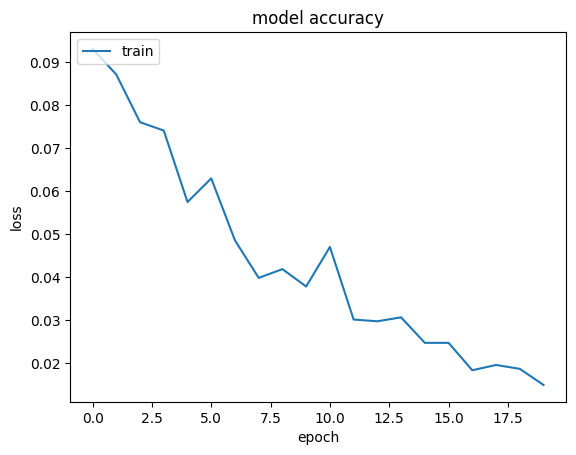

In [ ]:
plt.plot(model_details.history['loss'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# **Transfer Learning**

Vamos a usar una red ***MobileNet***


#Notas de clase:

Esta red ya esta entrenada en detectar ciertas caracteristicas de imagen, por ejemplo el modelo aprendio la estructura del ingles y ya podria identifica rel verbo, sujeto, adjetivo en español, es una transferencia del aprendizaje

en Keras applications hay muchas redes disponibles para usar con su descripcion, podemos usarlas para jugar con ellas.
Tambien esta la informacion de que necesitas para usarlas.

## **Cargando *[MobileNet](https://arxiv.org/abs/1704.04861)***

In [21]:
from keras.applications.mobilenet import MobileNet
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten, BatchNormalization
from keras.models import Sequential, Model
# ---- Cambiar el 'input_shape' de acuerdo al problema
base_model = MobileNet(weights='imagenet',include_top=False,input_shape=(192,192,3)) #Importa la red sin la última capa de 1000 neuronas

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## **Modificamos la red para nuestro problema**

Para esto, proponemos el uso del método **funcional** para definir la arquitectura

- Se establece el modelo base: pesos sinapticos. Se pueden poner las clases que escojamos y el tamaño que queramos que fue el que nos dio en entrenamiento anterior.

- Se inicia el ajuste fino de los pesos sinapticos.


In [22]:
x=base_model.output
x=GlobalAveragePooling2D()(x)

x=Dense(1024,activation='relu')(x) # Agregamos capa dense 1
x=Dense(1024,activation='relu')(x) # Agregamos capa dense 2
x=Dense(512,activation='relu')(x) # Agregamos capa dense 3

preds=Dense(2,activation='softmax')(x) # Capa de salida (Clase vs. No Clase)

A diferencia de la anterior, se intenta montar un modelo basado en funcional. X es la enrada de cada capa



**Congelamos pesos sinápticos para entrenar solo las últimas 4 capas**

In [23]:
model2 = Model(inputs=base_model.input,outputs=preds)
for layer in model2.layers[:20]:
    layer.trainable=False
for layer in model2.layers[20:]:
    layer.trainable=True

Aca se indico que se entrenara de la caa 20 en adelante.

In [24]:
model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1.0e-4), metrics = ['accuracy'])
model2.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 96, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 96, 96, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 96, 96, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 97, 97, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 48, 48, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 48, 48, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 48, 48, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 48, 48, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,853,890 (22.33 MB)

 Trainable params: 5,817,986 (22.19 MB)

 Non-trainable params: 35,904 (140.25 KB)

En este caso se crearon mas convoluciones y capas densas porque asi fue construida esa red neuronal.  que tomamos prestada.
Esta red tiene 5,853,890  pesos sinapticos con un espacio en disco de 22 MB
Es una red diseñada para eficiencia, tiene menos pesos sinapticos, ocupa menos espacio y es mas rapida en hacer la inferencia.
SOlo 35,904  son los que se van a entrenar.

## **Entrenamiento de la *MobileNet* adaptada**

In [25]:
model_details = model2.fit(train_generator,
                    batch_size = 32,
                    epochs = 10,
                    #validation_data=val_set,
                    #validation_split= 0.1,
                    callbacks=[checkpoint],
                    verbose=1)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.8634 - loss: 0.2325

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 894ms/step - accuracy: 0.9533 - loss: 0.0946
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9988 - loss: 0.0027
Epoch 2: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 546ms/step - accuracy: 0.9988 - loss: 0.0036
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 1.0000 - loss: 4.7071e-04
Epoch 3: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 643ms/step - accuracy: 1.0000 - loss: 6.5876e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.9986 - loss: 0.0034
Epoch 4: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 545ms/step - accuracy: 0.9982 - loss: 0.0045
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.9997 - loss: 8.6819e-04
Epoch 5: finished saving model to TB_Chest_Classification.keras
53/53 ━━━━━━━━━━━━━

La curva accuracy debe aumentar con el tiempo y el Error o perdida debe ir disminuyendo con el tiemo.

El conjunto de validacion es opcional. Si se tiene tiempo se puede implementar en un pequeño porcentaje de Training dataset.

## **Validación con otro subconjunto de datos**

Tomamos datos de validación y calculamos métricas de desempeño de la red.

Generamos las imágenes de validación

In [26]:
val_image_batch, val_label_batch = next(iter(valid_generator))
true_label_ids = np.argmax(val_label_batch, axis=-1)
print("Validation batch shape:", val_image_batch.shape)

Validation batch shape: (32, 192, 192, 3)


Calculamos el desempeño sobre el conjunto de **validación** de imágenes aplicado al modelo

In [27]:
scores = model2.evaluate(val_image_batch, val_label_batch)
print("Accuracy: %.2f%%" % (scores[1]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 2.4111e-05
Accuracy: 100.00%


In [28]:
tf_model_predictions = model2.predict(val_image_batch)
tf_pred_dataframe = pd.DataFrame(tf_model_predictions)
tf_pred_dataframe.columns = dataset_labels
print("Prediction results for the first elements")
tf_pred_dataframe

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction results for the first elements


,Normal,Tuberculosis
0,1.000000e+00,1.375017e-15
1,1.000000e+00,2.566318e-08
2,1.000000e+00,7.701802e-15
3,1.000000e+00,3.736535e-12
4,1.000000e+00,3.234495e-17
5,1.000000e+00,3.244351e-13
6,1.000000e+00,1.065339e-16
7,1.000000e+00,6.966816e-15
8,1.000000e+00,1.156445e-17
9,1.000000e+00,1.254351e-10


Lo ideal es sacar medidas estadisticas, porque los pesos sinapticos con los que uno empieza inician con valores aleatorios, si se reinicia el entrenamiento entonces se toman otros pesos sinapticos. Lo ideal es sacar las medidas estadisticas para saber que pesos funcionan mejor.

**Matriz de Confusión del Conjunto de Validación**

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_hat_te2 = model2.predict(val_image_batch,verbose=1)
y_hat_te2 = np.argmax(y_hat_te2,axis=1)
print(classification_report(true_label_ids, y_hat_te2)) #, target_names = names))
print(confusion_matrix(true_label_ids, y_hat_te2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00         2

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

[[30  0]
 [ 0  2]]


**Figuras del Entrenamiento**

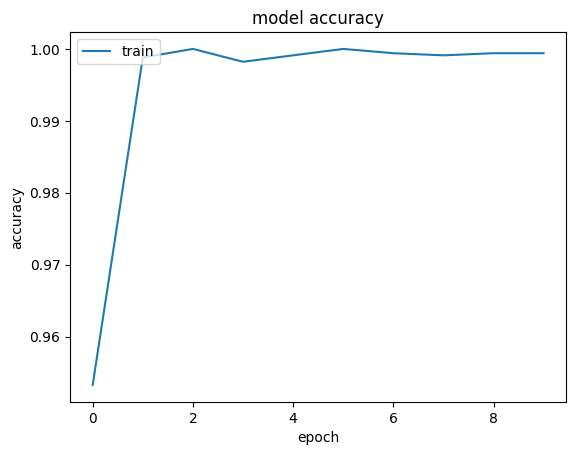

In [30]:
plt.plot(model_details.history['accuracy'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

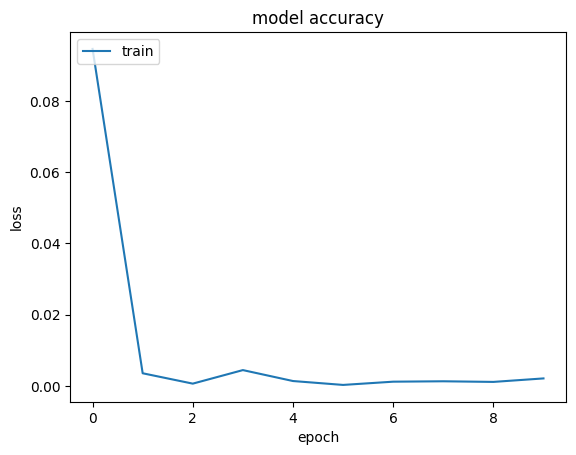

In [31]:
plt.plot(model_details.history['loss'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()